### Load a dataset

In [7]:
import pandas as pd
import numpy as np
import visualize_scores as visualize
import metrics
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
scores = pd.read_csv("scores_all.csv")

In [9]:
p11_dataset = scores[scores['Prompt'] == "p11"]
p11_dataset.head(10)

,Prompt,Assignment,EssayType,Writer,Grader,Issues,Evidence,Context,Position,Conclusions,Total,HasZero,Issues_zero,Evidence_zero,Context_zero,Position_zero,Conclusions_zero
790,p11,A1,generate,chatgpt,claude,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
791,p11,A1,generate,chatgpt,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
792,p11,A1,generate,chatgpt,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
793,p11,A1,generate,claude,chatgpt,4.0,3.0,3.0,3.0,3.0,16.0,False,False,False,False,False,False
794,p11,A1,generate,claude,gemini,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
795,p11,A1,generate,claude,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
796,p11,A1,generate,gemini,chatgpt,3.0,3.0,2.0,3.0,3.0,14.0,False,False,False,False,False,False
797,p11,A1,generate,gemini,claude,4.0,4.0,3.0,4.0,4.0,19.0,False,False,False,False,False,False
798,p11,A1,generate,gemini,grok,4.0,4.0,4.0,4.0,4.0,20.0,False,False,False,False,False,False
799,p11,A1,generate,grok,chatgpt,4.0,3.0,3.0,4.0,3.0,17.0,False,False,False,False,False,False


In [10]:
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']

heatmap_data = p11_dataset.groupby('Grader')[dimensions].mean()

heatmap_data

,Issues,Evidence,Context,Position,Conclusions
Grader,,,,,
chatgpt,3.888889,3.500000,3.500000,3.611111,3.555556
claude,3.777778,3.777778,3.555556,3.833333,3.833333
gemini,4.000000,3.944444,4.000000,4.000000,4.000000
grok,4.000000,4.000000,4.000000,4.000000,4.000000


In [11]:
p11_tuned = scores[(scores['Prompt'] == "p11") & (scores['EssayType'] == "tune")]

In [12]:
models = ['chatgpt', 'claude', 'gemini', 'grok']
display_models = ['ChatGPT 5.2', 'Claude Sonnet 4.5', 'Gemini 3 Flash Preview', 'Grok 4.1 Fast Reasoning']
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']


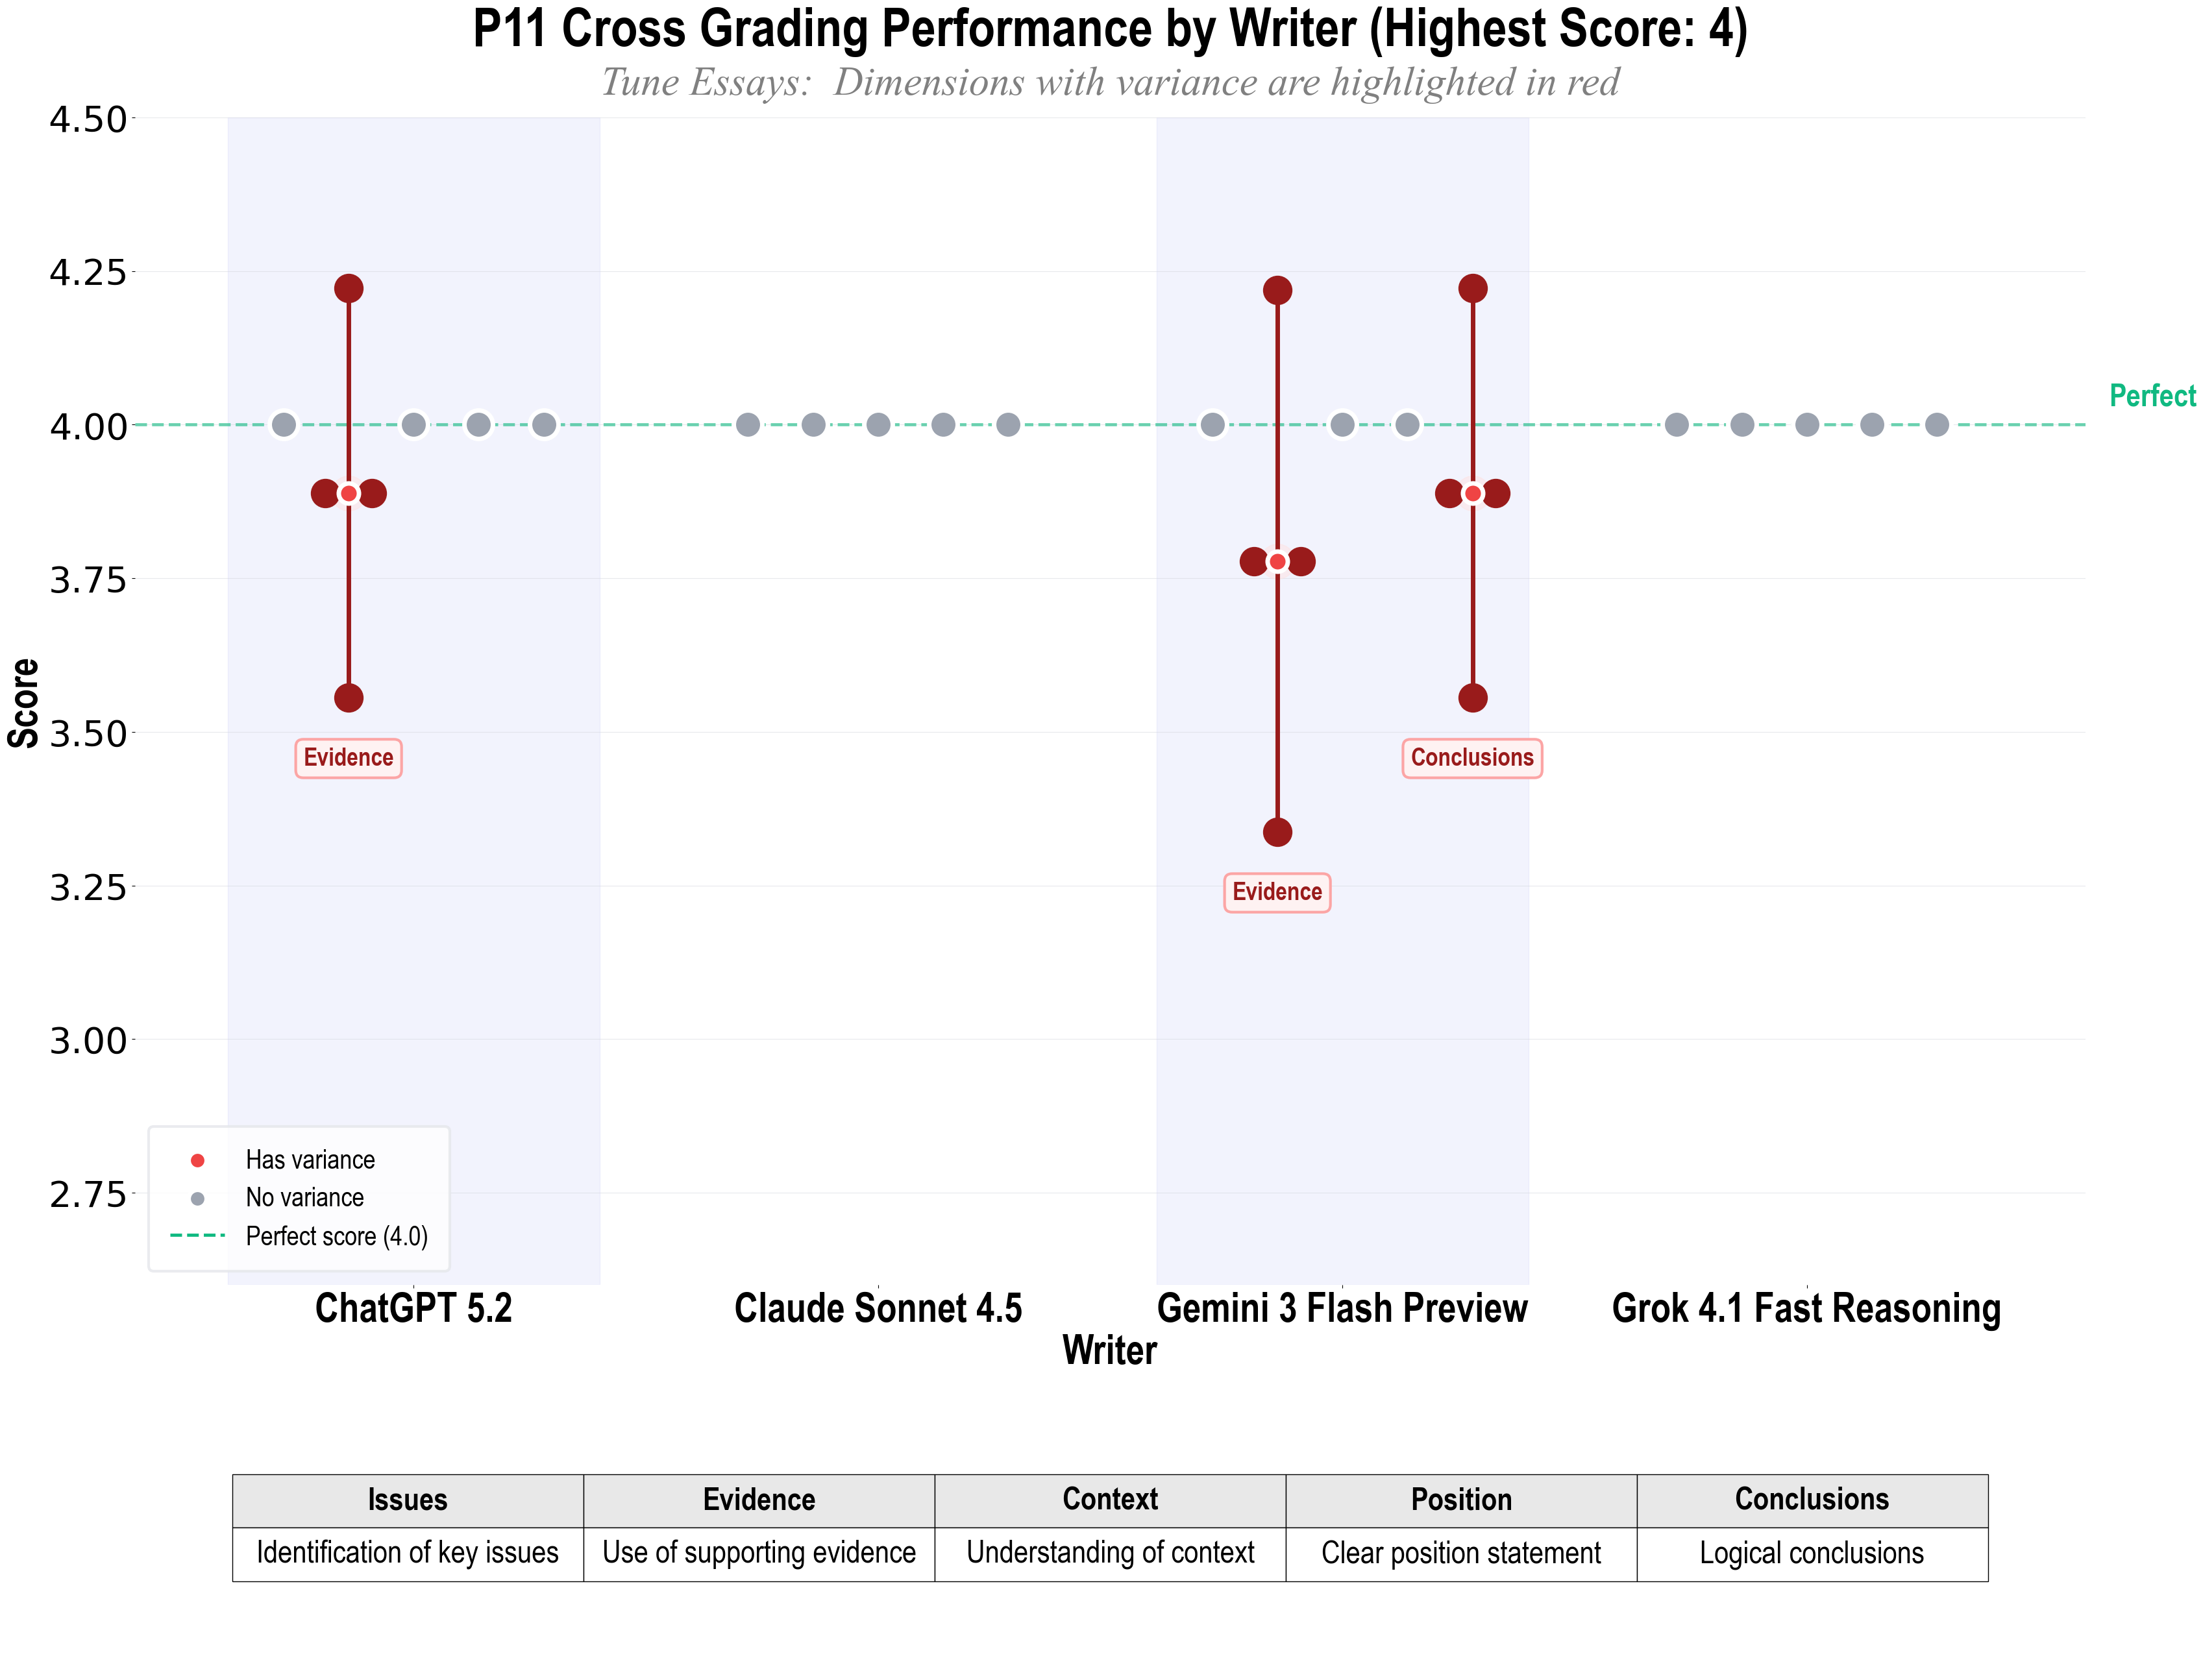

In [19]:

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(34, 26),
    gridspec_kw={'height_ratios': [4, 1]}
)
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

# Add subtle background bands for each model
for m_idx in range(len(models)):
    if m_idx % 2 == 0:
        ax1.axvspan(m_idx - 0.4, m_idx + 0.4, alpha=0.08, color='#6366f1', zorder=0)

# Plot data directly from dataset
for m_idx, model in enumerate(models):
    model_data = p11_tuned[p11_tuned['Writer'] == model]
    
    for d_idx, dim in enumerate(dimensions):
        mean_score = model_data[dim].mean()
        std_score = model_data[dim].std()
        
        # Handle NaN
        if np.isnan(std_score):
            std_score = 0.0
        
        x = m_idx + (d_idx - 2) * 0.14
        y = mean_score
        
        has_variance = std_score > 0.01
        
        if has_variance:
            # Glow effect
            ax1.scatter(x, y, color='#fee2e2', s=1500, zorder=3, alpha=0.5)
            
            # Error bars
            ax1.plot([x, x], [y - std_score, y + std_score], color='#991b1b', 
                    linewidth=5, zorder=4, solid_capstyle='round')
            ax1.scatter([x, x], [y - std_score, y + std_score], color='#991b1b', s=1000, zorder=5)
            ax1.plot([x - 0.05, x + 0.05], [y, y], color='#991b1b', linewidth=5, zorder=4)
            ax1.scatter([x - 0.05, x + 0.05], [y, y], color='#991b1b', s=1000, zorder=5)
            
            # Red dot
            ax1.scatter(x, y, color='#ef4444', s=500, zorder=6, edgecolors='white', linewidths=5)
            
            # Label
            ax1.annotate(
                dim,
                xy=(x, y - std_score - 0.08),
                ha='center', va='top',
                fontsize=28, fontweight='bold', fontfamily='Arial Narrow', color='#991b1b',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef2f2', edgecolor='#fca5a5', linewidth=3),
                zorder=7
            )
        else:
            # Gray glow
            ax1.scatter(x, y, color='#e5e7eb', s=1000, zorder=3, alpha=0.4)
            
            # Gray dot
            ax1.scatter(x, y, color='#9ca3af', s=1000, zorder=6, edgecolors='white', linewidths=5)

# Styling
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(display_models, fontsize=45, fontfamily='Arial Narrow', fontweight='bold', color='black')
ax1.set_xlabel('Writer', fontsize=45, fontfamily='Arial Narrow', fontweight='bold', color='black')
ax1.set_ylabel('Score', fontsize=45, fontfamily='Arial Narrow', fontweight='bold', color='black')
ax1.tick_params(axis='y', labelsize=40)
ax1.set_ylim(2.6, 4.5)
ax1.set_xlim(-0.6, len(models) - 0.4)

# Grid
ax1.yaxis.grid(True, linestyle='-', alpha=0.5, color='#d1d5db', zorder=0)
ax1.set_axisbelow(True)

# Clean spines
for spine in ax1.spines.values():
    spine.set_visible(False)

# Perfect score line
ax1.axhline(y=4.0, color='#10b981', linestyle='--', linewidth=3.5, alpha=0.6, zorder=1)
ax1.text(len(models) - 0.35, 4.02, 'Perfect', fontsize=35, fontfamily='Arial Narrow', 
        color='#10b981', fontweight='bold', va='bottom')

# Variance legend (upper right)
variance_handles = [
    plt.scatter([], [], color='#ef4444', s=400, edgecolors='white', linewidths=5, label='Has variance'),
    plt.scatter([], [], color='#9ca3af', s=400, edgecolors='white', linewidths=5, label='No variance'),
    plt.Line2D([0], [0], color='#10b981', linestyle='--', linewidth=3.5, label='Perfect score (4.0)')
]
leg = ax1.legend(handles=variance_handles, loc='lower left', frameon=True, facecolor='white', 
                 fontsize=30, edgecolor='#e5e7eb', borderpad=0.8)
leg.get_frame().set_linewidth(3)
for text in leg.get_texts():
    text.set_fontfamily('Arial Narrow')

# Title
ax1.set_title('P11 Cross Grading Performance by Writer (Highest Score: 4)', 
             fontsize=60, fontfamily='Arial Narrow', fontweight='bold', color='black', pad=80)

# Subtitle
ax1.text(0.5, 1.02, 'Tune Essays:  Dimensions with variance are highlighted in red', 
        transform=ax1.transAxes, ha='center', fontsize=45, fontfamily='Times New Roman', 
        color='gray', style='italic')

# Legend table (ax2)
ax2.set_facecolor('white')
ax2.axis('off')

table_data = [
    ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions'],
    ['Identification of key issues', 'Use of supporting evidence', 'Understanding of context', 'Clear position statement', 'Logical conclusions']
]

table = ax2.table(
    cellText=table_data,
    loc='center',
    cellLoc='center',
    colWidths=[0.18, 0.18, 0.18, 0.18, 0.18]
)

table.auto_set_font_size(False)
table.set_fontsize(35)
table.scale(1, 4)

# Style table
for c in range(5):
    table[0, c].set_facecolor('#e8e8e8')
    table[0, c].set_text_props(fontweight='bold', fontfamily='Arial Narrow', color='black')
    table[1, c].set_facecolor('white')
    table[1, c].set_text_props(fontfamily='Arial Narrow', color='black')

plt.tight_layout()
plt.savefig('p11_tuned_crosshair.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()


### Grading Scores in Cross-Model Evaluation

In [6]:
writers = ['chatgpt', 'claude', 'gemini', 'grok']
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']

In [7]:
for p in p11_dataset['Prompt'].unique():
    subset = p11_dataset[p11_dataset['Prompt'] == p]
    print ("prompt", p)
    print(subset.groupby(['Assignment', 'EssayType']).size().to_string())

prompt p11
Assignment  EssayType
A1          generate     12
            tune         12
A2          generate     12
            tune         12
A3          generate     12
            tune         12


In [8]:
stats_df = metrics.compute_cross_grading_scores(p11_dataset, writers, dimensions, grader=None)
stats_df.tail(10)
len(stats_df)

#group by essaytype and writer and grader and dimension
# 2 essays x 2 writers x 4 graders x 5 dimensions = 160 rows 


160

In [9]:
grader_df = metrics.compute_cross_grading_scores(p11_dataset, writers, dimensions, grader="claude")

grader_df.head(20)

,EssayType,Writer,Grader,Dimension,N,Mean,Std,Bar_bottom,Bar_top,Values
0,generate,chatgpt,claude,Issues,3,3.6667,0.5774,3.0893,4.2440,"[4.0, 4.0, 3.0]"
1,generate,chatgpt,claude,Evidence,3,4.0000,0.0000,4.0000,4.0000,"[4.0, 4.0, 4.0]"
2,generate,chatgpt,claude,Context,3,3.3333,0.5774,2.7560,3.9107,"[3.0, 4.0, 3.0]"
3,generate,chatgpt,claude,Position,3,4.0000,0.0000,4.0000,4.0000,"[4.0, 4.0, 4.0]"
4,generate,chatgpt,claude,Conclusions,3,4.0000,0.0000,4.0000,4.0000,"[4.0, 4.0, 4.0]"
5,generate,claude,claude,Issues,0,NaN,0.0000,NaN,NaN,[]
6,generate,claude,claude,Evidence,0,NaN,0.0000,NaN,NaN,[]
7,generate,claude,claude,Context,0,NaN,0.0000,NaN,NaN,[]
8,generate,claude,claude,Position,0,NaN,0.0000,NaN,NaN,[]
9,generate,claude,claude,Conclusions,0,NaN,0.0000,NaN,NaN,[]


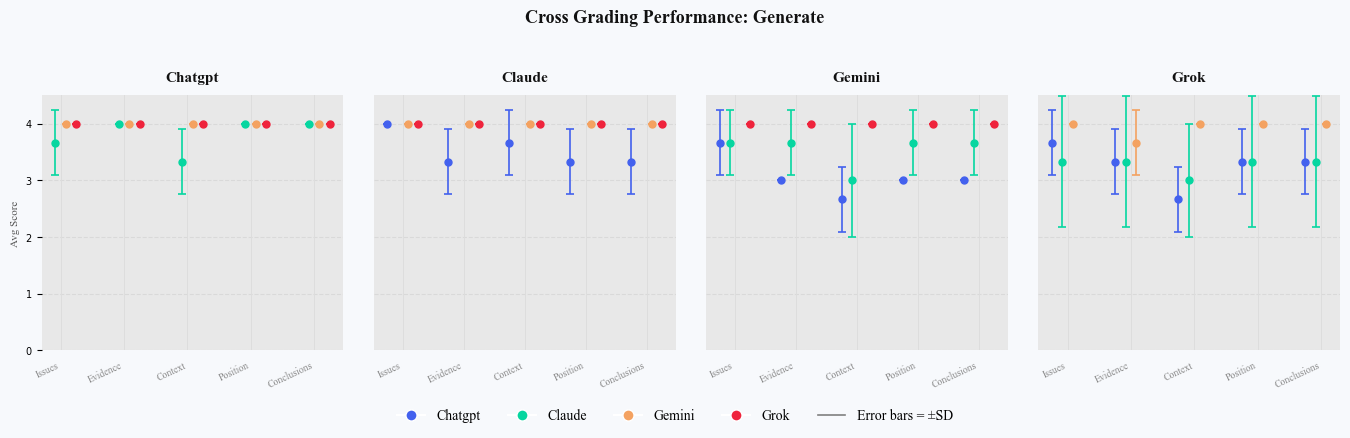

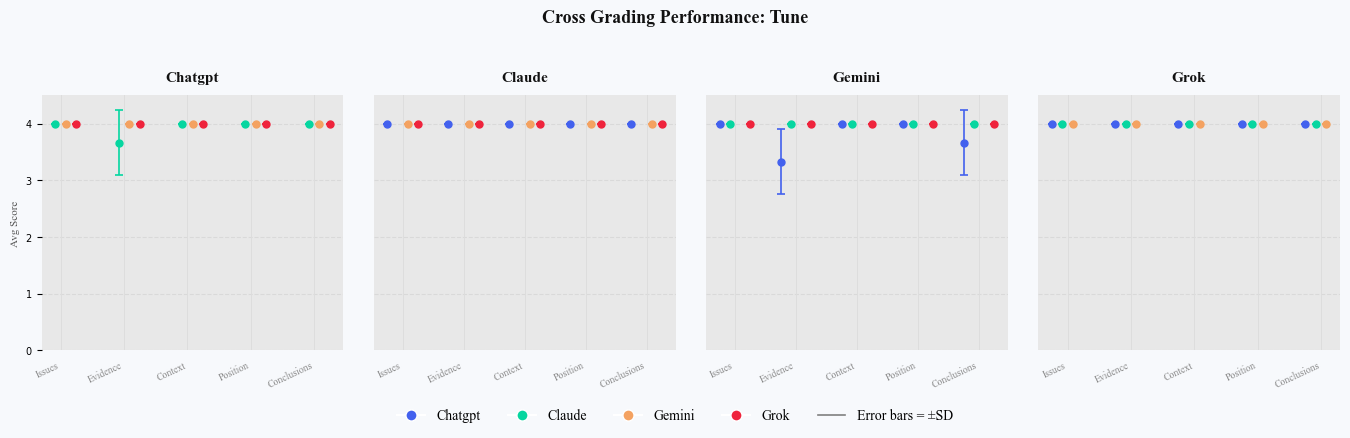

In [10]:
visualize.cross_grading_scores_by_essaytype(stats_df, writers, dimensions)

The chart highlights the grader bias models highlight through cross-evaluation.

- ChatGPT as grader is consistently lower.
- Gemini and Grok are consistently high and tight.
- Claude sits in between but shows more variance in all dimensions.

Analyze writer by writer:

ChatGPT (writer):
- In Generate, Claude grading shows large variance in Context.
- In Tune, everything tightens and rises.
- Interpretation: tuning stabilizes how others perceive ChatGPT’s structure.

Claude (writer):
- ChatGPT consistently penalizes Claude-written essays, and ChatGPT grading show variations for all of dimension unless the issue.
- For tuned essays, ChatGPT grades on evidence dimension at 3, not improving after tuned.

Gemini (writer):
- Both ChatGPT and Gemini show high grading variation in most dimensions.


Grok (writer):
-  Grok just gives 4.0 to all models no matter who wrote it.

### Writer Performance by Assignment 

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D 

In [12]:
assignment_bias = metrics.compute_grading_bias_by_assignment(p11_dataset, writers, dimensions)

assignment_bias.head(10)

len(assignment_bias)

#group by 2 essay types x 4 writers x 3 assignments x 5 dimensions = 120 rows

120

In [13]:
assignment_bias.head(20)

#Issues Caculation Example

#Consensus  = (4 + 3 + 4) / 3 = 3.67 

#Abs_Bias per grader:
  #Claude: |4 - 3.67| = 0.33
  #Gemini: |3 - 3.67| = 0.67  (rounded from 0.666...)
  #Grok:   |4 - 3.67| = 0.33

#Bias vector = [0.67, 0.33, 0.33]  

#Mean_AbsBias = (0.67 + 0.33 + 0.33) / 3 = 0.4444  

,Prompt,EssayType,Writer,Assignment,Dimension,N,AbsBiasValues,Consensus,Mean_AbsBias
0,p11,generate,chatgpt,A1,Issues,3,"[0.0, 0.0, 0.0]",4.00,0.0000
1,p11,generate,chatgpt,A1,Evidence,3,"[0.0, 0.0, 0.0]",4.00,0.0000
2,p11,generate,chatgpt,A1,Context,3,"[0.67, 0.33, 0.33]",3.67,0.4444
3,p11,generate,chatgpt,A1,Position,3,"[0.0, 0.0, 0.0]",4.00,0.0000
4,p11,generate,chatgpt,A1,Conclusions,3,"[0.0, 0.0, 0.0]",4.00,0.0000
5,p11,generate,chatgpt,A2,Issues,3,"[0.0, 0.0, 0.0]",4.00,0.0000
6,p11,generate,chatgpt,A2,Evidence,3,"[0.0, 0.0, 0.0]",4.00,0.0000
7,p11,generate,chatgpt,A2,Context,3,"[0.0, 0.0, 0.0]",4.00,0.0000
8,p11,generate,chatgpt,A2,Position,3,"[0.0, 0.0, 0.0]",4.00,0.0000
9,p11,generate,chatgpt,A2,Conclusions,3,"[0.0, 0.0, 0.0]",4.00,0.0000


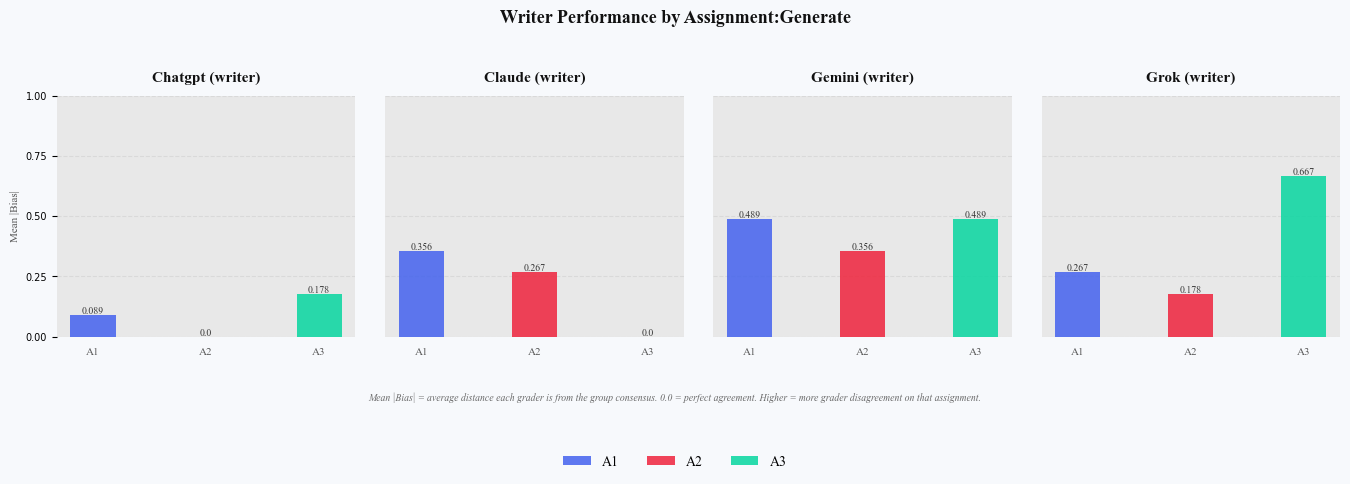

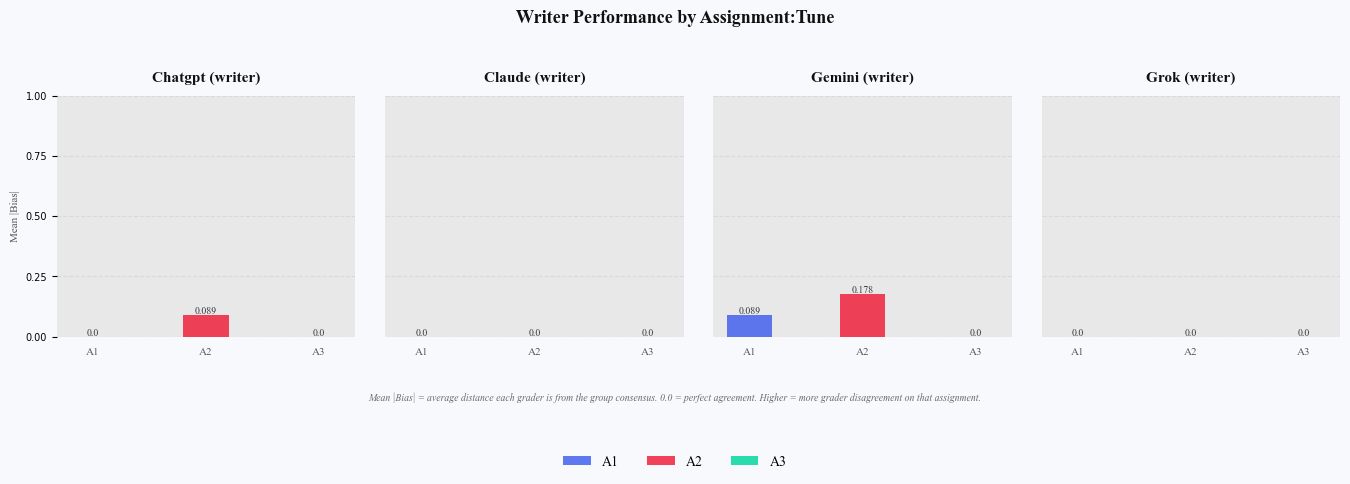

In [14]:
visualize.grading_bias_by_assignment(assignment_bias, writers, target_writer=None)

Generate essays:

- A3 is consistently the largest contributor.
- A2 is usually the smallest.

Tuned essays:

- Bias magnitude is roughly half (or less) of Generate.
- No extreme spikes like 0.53.
- Disagreement is more evenly distributed.

In [15]:
from scipy import stats

# Retrieve data
conclusions = assignment_bias[assignment_bias['Dimension'] == 'Conclusions']['Mean_AbsBias']
context = assignment_bias[assignment_bias['Dimension'] == 'Context']['Mean_AbsBias']
evidence = assignment_bias[assignment_bias['Dimension'] == 'Evidence']['Mean_AbsBias']
issues = assignment_bias[assignment_bias['Dimension'] == 'Issues']['Mean_AbsBias']
position = assignment_bias[assignment_bias['Dimension'] == 'Position']['Mean_AbsBias']


In [16]:
# P-value
conclusions_t, conclusions_p = stats.ttest_1samp(conclusions, popmean=0)
context_t, context_p = stats.ttest_1samp(context, popmean=0)
evidence_t, evidence_p = stats.ttest_1samp(evidence, popmean=0)
issues_t, issues_p = stats.ttest_1samp(issues, popmean=0)
position_t, position_p = stats.ttest_1samp(position, popmean=0)

In [17]:
results = {
    'Conclusions': (conclusions_t, conclusions_p),
    'Context':     (context_t,     context_p),
    'Evidence':    (evidence_t,    evidence_p),
    'Issues':      (issues_t,      issues_p),
    'Position':    (position_t,    position_p)
}

In [18]:
for dim, (t, p) in sorted(results.items(), key=lambda x: x[1][0]):

    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    
    print(dim, round(t, 2), round(p, 4), stars)

Issues 2.1 0.047 *
Position 3.02 0.0061 **
Conclusions 3.33 0.0029 **
Context 3.5 0.0019 **
Evidence 4.05 0.0005 ***


==> All 5 dimensions show statistically significant grader bias. Evidence is the hardest dimension for 4 AI models to grade on.

### Do two specific models grade differently by each dimension from each other?

In [19]:
dimensions = ['Issues', 'Evidence', 'Context', 'Position', 'Conclusions']
pair_names = ['Claude vs Gemini', 'Claude vs Grok', 'Claude vs ChatGPT',
              'Gemini vs Grok',   'Gemini vs ChatGPT', 'Grok vs ChatGPT']

In [20]:
rows = []

for dim in dimensions:
    for name, grader_a, grader_b in [
        ('Claude vs Gemini',  'claude',  'gemini'),
        ('Claude vs Grok',    'claude',  'grok'),
        ('Claude vs ChatGPT', 'claude',  'chatgpt'),
        ('Gemini vs Grok',    'gemini',  'grok'),
        ('Gemini vs ChatGPT', 'gemini',  'chatgpt'),
        ('Grok vs ChatGPT',   'grok',    'chatgpt'),
    ]:
        a = p11_dataset[p11_dataset['Grader'] == grader_a][dim].values
        b = p11_dataset[p11_dataset['Grader'] == grader_b][dim].values

        if np.std(a - b) == 0:
            p = 1.0
        else:
            t, p = stats.ttest_rel(a, b)
            p = round(p, 4)

        rows.append({'Pair': name, 'Dimension': dim, 'P_value': p})

In [21]:
results_df = pd.DataFrame(rows)
results_df

,Pair,Dimension,P_value
0,Claude vs Gemini,Issues,0.1037
1,Claude vs Grok,Issues,0.1037
2,Claude vs ChatGPT,Issues,0.3313
3,Gemini vs Grok,Issues,1.0000
4,Gemini vs ChatGPT,Issues,0.1631
5,Grok vs ChatGPT,Issues,0.1631
6,Claude vs Gemini,Evidence,0.0827
7,Claude vs Grok,Evidence,0.1037
8,Claude vs ChatGPT,Evidence,0.0962
9,Gemini vs Grok,Evidence,0.3313


In [22]:
pval_matrix  = results_df.pivot(index='Pair', columns='Dimension', values='P_value')

pval_matrix

Dimension,Conclusions,Context,Evidence,Issues,Position
Pair,,,,,
Claude vs ChatGPT,0.0560,0.6676,0.0962,0.3313,0.1037
Claude vs Gemini,0.1872,0.0160,0.0827,0.1037,0.1872
Claude vs Grok,0.1872,0.0160,0.1037,0.1037,0.1872
Gemini vs ChatGPT,0.0018,0.0081,0.0018,0.1631,0.0043
Gemini vs Grok,1.0000,1.0000,0.3313,1.0000,1.0000
Grok vs ChatGPT,0.0018,0.0081,0.0007,0.1631,0.0043


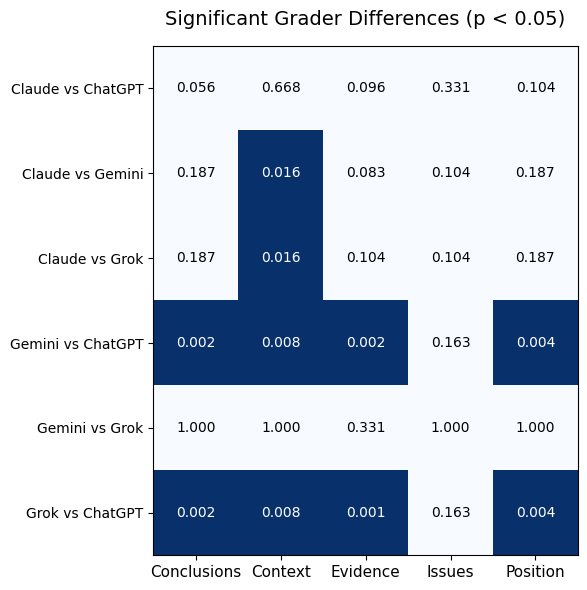

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))

# Create binary matrix: 1 = significant, 0 = not
binary_matrix = (pval_matrix.values.astype(float) < 0.05).astype(int)

for i in range(len(pval_matrix.index)):
    for j in range(len(pval_matrix.columns)):
        p = pval_matrix.iloc[i, j]
        color = 'white' if p < 0.05 else 'black'
        ax.text(j, i, f'{p:.3f}', ha='center', va='center', fontsize=10, color=color)

im = ax.imshow(binary_matrix, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(pval_matrix.columns)))
ax.set_xticklabels(pval_matrix.columns, fontsize=11)
ax.set_yticks(range(len(pval_matrix.index)))
ax.set_yticklabels(pval_matrix.index, fontsize=10)

ax.set_title('Significant Grader Differences (p < 0.05)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

- No pair shows significant difference on Issues.
- ChatGPT is the primary driver of grader disagreement, showing statistically significant differences from Claude, Gemini, and Grok across Evidence, Conclusions, and Position dimensions.
- Claude, Gemini, and Grok consistently gave similar scores to each other across all dimensions.